##CS7DS2 - Optimisation Algorithms for Data Analysis - Week 4 Assignment
Name : Swetha Sekar

Student ID : 25336453

In [4]:
import numpy as np
import matplotlib.pyplot as plt

##Question - 1

The given function is (x,y)=x²+100y², with a starting point of (x0​,y0​)=(2,2). The gradients of this function are ▽f = [2x, 200y], and the Hessian matrix is given as diag(2, 200); it has maximum eigenvalue L = 200 and minimum value μ = 2,
thus giving a condition number k = L/μ = 100. This ratio of 100:1 is extreme, and it is the main cause of ill-conditioning and anisotropic curvature. This explains why the trajectory zigzags severely along the narrow y valley while slowly growing in the x axis. The optimisers are run for 200 iterations.


In [7]:
#question - 1

def construct_polyak(grad_q1f1, f_q1f1, x0, f_star, itrs):
  x = x0.copy().astype(float)
  hist = [x.copy()]
  f_vals = [f_q1f1(*x)]
  eps = 1e-10

  for _ in range(itrs):
    gr = grad_q1f1(*x)
    steps = (f_q1f1(*x) - f_star) / (np.dot(gr, gr) + eps)
    x -= steps * gr
    hist.append(x.copy())
    f_vals.append(f_q1f1(*x))

  return np.array(hist), np.array(f_vals)

def construct_rmsprop(grad_q1f1, f_q1f1, x0, alpha, beta, itrs, eps=1e-8):
  x = x0.copy().astype(float)
  v = np.zeros_like(x)
  hist = [x.copy()]
  f_vals = [f_q1f1(*x)]

  for _ in range(itrs):
    gr = grad_q1f1(*x)
    v = beta * v + (1 - beta) * gr**2
    x -= alpha * gr / (np.sqrt(v) + eps)
    hist.append(x.copy())
    f_vals.append(f_q1f1(*x))

  return np.array(hist), np.array(f_vals)

def construct_heavyball(grad_q1f1, f_q1f1, x0, alpha, beta, itrs):
  x = x0.copy().astype(float)
  m_vec = np.zeros_like(x)
  hist = [x.copy()]
  f_vals = [f_q1f1(*x)]

  for _ in range(itrs):
    gr = grad_q1f1(*x)
    m_vec = beta * m_vec + gr
    x -= alpha * m_vec
    hist.append(x.copy())
    f_vals.append(f_q1f1(*x))

  return np.array(hist), np.array(f_vals)

def construct_adam(grad_q1f1, f_q1f1, x0, alpha, beta1, beta2, itrs, eps=1e-8):
  x = x0.copy().astype(float)
  m_vec = np.zeros_like(x)
  v_vec = np.zeros_like(x)
  hist = [x.copy()]
  f_vals = [f_q1f1(*x)]

  for t in range(1, itrs + 1):
    gr = grad_q1f1(*x)
    m_vec = beta1 * m_vec + (1 - beta1) * gr
    v_vec = beta2 * v_vec + (1 - beta2) * gr**2
    m_hat = m_vec / (1 - beta1**t)
    v_hat = v_vec / (1 - beta2**t)
    x -= alpha * m_hat / (np.sqrt(v_hat) + eps)
    hist.append(x.copy())
    f_vals.append(f_q1f1(*x))

  return np.array(hist), np.array(f_vals)

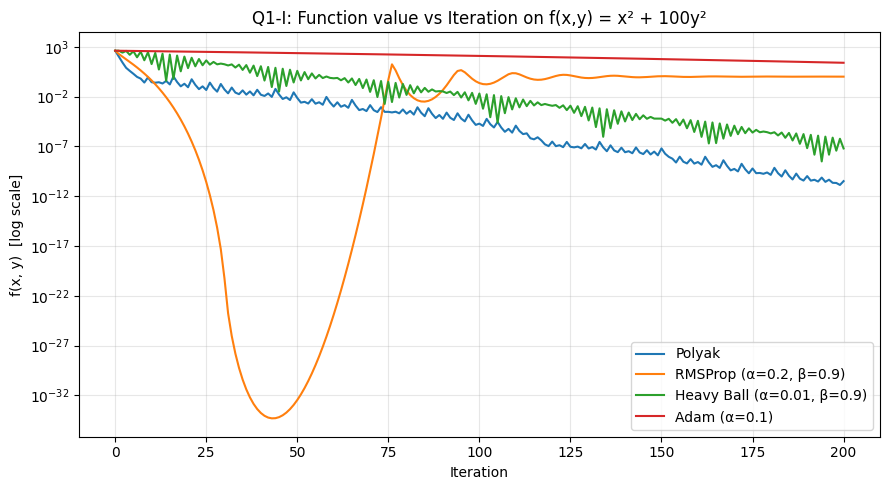

In [10]:
#question 1 - (I)

x0_q1 = np.array([2.0, 2.0])
itrs_q1 = 200
f_star_q1 = 0.0

q1f1 = lambda x, y: x**2 + 100 * y**2
grad_q1f1 = lambda x, y: np.array([2*x, 200*y])

xs_polyak, fvals_polyak = construct_polyak(grad_q1f1, q1f1, x0_q1, f_star_q1, itrs_q1)
xs_rmsprop, fvals_rmsprop = construct_rmsprop(grad_q1f1, q1f1, x0_q1, alpha=0.2, beta=0.9, itrs=itrs_q1)
xs_heavyball, fvals_heavyball = construct_heavyball(grad_q1f1, q1f1, x0_q1, alpha=0.01, beta=0.9, itrs=itrs_q1)
xs_adam, fvals_adam = construct_adam(grad_q1f1, q1f1, x0_q1, alpha=0.01, beta1=0.9, beta2=0.999, itrs=itrs_q1)

fig, ax = plt.subplots(figsize=(9, 5))
iters = np.arange(itrs_q1 + 1)
ax.semilogy(iters, fvals_polyak, label='Polyak')
ax.semilogy(iters, fvals_rmsprop, label='RMSProp (α=0.2, β=0.9)')
ax.semilogy(iters, fvals_heavyball, label='Heavy Ball (α=0.01, β=0.9)')
ax.semilogy(iters, fvals_adam, label='Adam (α=0.1)')
ax.set_xlabel('Iteration')
ax.set_ylabel('f(x, y)  [log scale]')
ax.set_title('Q1-I: Function value vs Iteration on f(x,y) = x² + 100y²')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('q1_part1_fval.png', bbox_inches='tight')

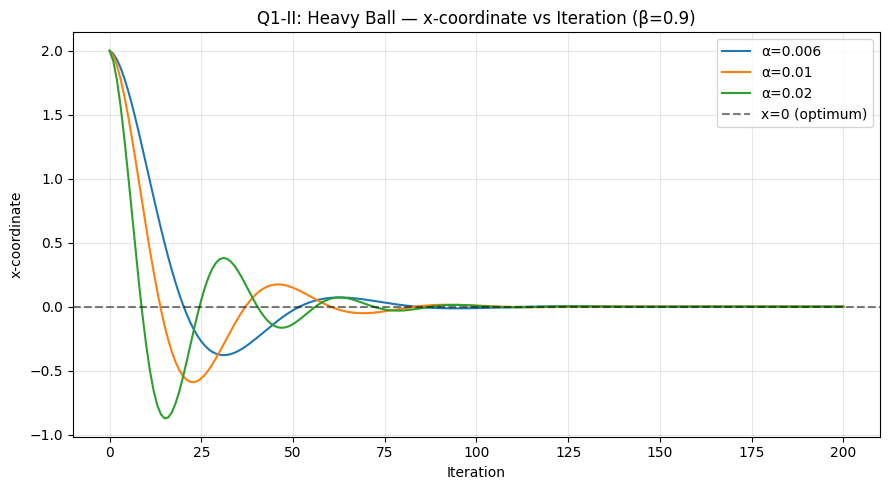

In [15]:
#question 1 - (II)

alphas_vals_hb = [0.006, 0.01, 0.02]
fig, ax = plt.subplots(figsize=(9, 5))
for a in alphas_vals_hb:
    hist, _ = construct_heavyball(grad_q1f1, q1f1, x0_q1, alpha=a, beta=0.9, itrs=itrs_q1)
    x_coords = hist[:, 0]
    x_coords_clipped = np.clip(x_coords, -50, 50)
    ax.plot(np.arange(itrs_q1 + 1), x_coords_clipped, label=f'α={a}')

ax.set_xlabel('Iteration')
ax.set_ylabel('x-coordinate')
ax.set_title('Q1-II: Heavy Ball — x-coordinate vs Iteration (β=0.9)')
ax.axhline(0, color='black', linestyle='--', alpha=0.5, label='x=0 (optimum)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1_part2_hb_stability.png', bbox_inches='tight')

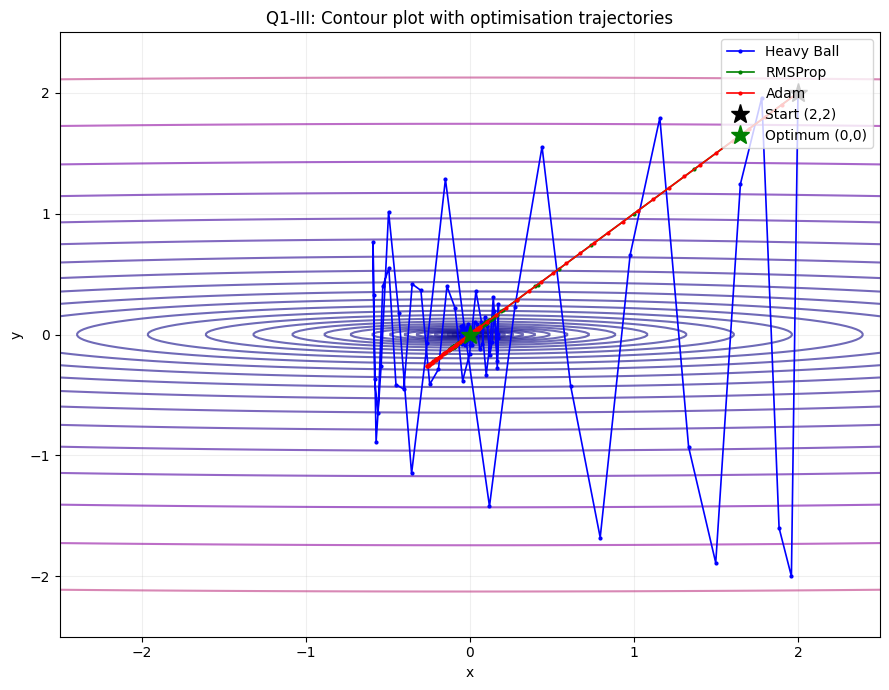

In [18]:
#question 1 - (III)

x_grid = np.linspace(-2.5, 2.5, 400)
y_grid = np.linspace(-2.5, 2.5, 400)
x_mesh, y_mesh = np.meshgrid(x_grid, y_grid)
Z = q1f1(x_mesh, y_mesh)

hist_hb, _ = construct_heavyball(grad_q1f1, q1f1, x0_q1, alpha=0.01, beta=0.9, itrs=itrs_q1)
hist_rms, _ = construct_rmsprop(grad_q1f1, q1f1, x0_q1, alpha=0.2, beta=0.9, itrs=itrs_q1)
hist_adam, _ = construct_adam(grad_q1f1, q1f1, x0_q1, alpha=0.1, beta1=0.9, beta2=0.999, itrs=itrs_q1)

fig, ax = plt.subplots(figsize=(9, 7))
levels = np.logspace(-2, 3, 30)
cs = ax.contour(x_mesh, y_mesh, Z, levels=levels, cmap='plasma', alpha=0.6)

ax.plot(hist_hb[:, 0],  hist_hb[:, 1],  'b-o', markersize=2, linewidth=1.2, label='Heavy Ball')
ax.plot(hist_rms[:, 0], hist_rms[:, 1], 'g-o', markersize=2, linewidth=1.2, label='RMSProp')
ax.plot(hist_adam[:,0], hist_adam[:,1],  'r-o', markersize=2, linewidth=1.2, label='Adam')

ax.plot(*x0_q1, 'k*', markersize=14, label='Start (2,2)')
ax.plot(0, 0, 'g*', markersize=14, label='Optimum (0,0)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Q1-III: Contour plot with optimisation trajectories')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('q1_part3_contour.png', bbox_inches='tight')

##Question - 2

The given function here is f(x,y) = (1−x)² + 100(y−x²)², run from (x0, y) = (−1.25, 0.5) for 3000 iterations, and the minimum f* is 0 at (1,1). The gradients of this function are calculated as ∂f/∂x = −2(1−x) − 400x(y−x²); ∂f/∂y = 200(y−x²). Unlike the previous function, the Hessian varies across the landscape, making it a non-convex function, and it is highly non-linear and has ill-conditioned local curvature. The global minimum is at the bottom of the curved parabolic valley y = x2.

In [25]:
#question - 2

def grad_q2f2(x, y):
  dfdx = -2*(1-x) - 400*x*(y-x**2)
  dfdy = 200*(y-x**2)
  return np.array([dfdx, dfdy])

q2f2 = lambda x, y: (1 - x)**2 + 100 * (y - x**2)**2

x0_q2 = np.array([-1.25, 0.5])
itrs_q2 = 3000


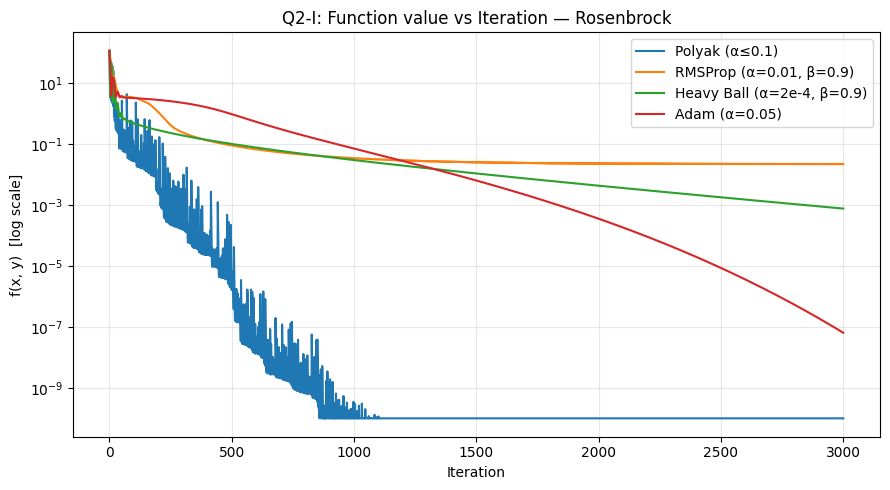

In [27]:
#question 2 - (I)

hist2_polyak, fv2_polyak = construct_polyak(grad_q2f2, q2f2, x0_q2, f_star=0.0, itrs=itrs_q2)
hist2_rmsprop, fv2_rmsprop = construct_rmsprop(grad_q2f2, q2f2, x0_q2, alpha=0.01, beta=0.9, itrs=itrs_q2)
hist2_hb, fv2_hb = construct_heavyball(grad_q2f2, q2f2, x0_q2, alpha=2e-4, beta=0.9, itrs=itrs_q2)
hist2_adam, fv2_adam = construct_adam(grad_q2f2, q2f2, x0_q2, alpha=0.05, beta1=0.9, beta2=0.999, itrs=itrs_q2)

fig, ax = plt.subplots(figsize=(9, 5))
iters2 = np.arange(itrs_q2 + 1)
ax.semilogy(iters2, np.maximum(fv2_polyak, 1e-10), label='Polyak (α≤0.1)')
ax.semilogy(iters2, np.maximum(fv2_rmsprop, 1e-10), label='RMSProp (α=0.01, β=0.9)')
ax.semilogy(iters2, np.maximum(fv2_hb, 1e-10), label='Heavy Ball (α=2e-4, β=0.9)')
ax.semilogy(iters2, np.maximum(fv2_adam, 1e-10), label='Adam (α=0.05)')
ax.set_xlabel('Iteration')
ax.set_ylabel('f(x, y)  [log scale]')
ax.set_title('Q2-I: Function value vs Iteration — Rosenbrock')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('q2_part1_fval.png', bbox_inches='tight')

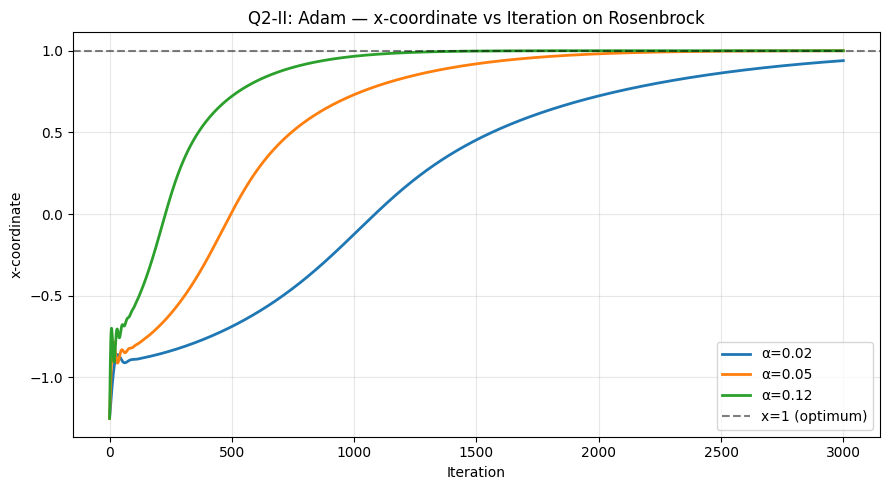

In [28]:
#question 2 - (II)

alphas_adam = [0.02, 0.05, 0.12]
fig, ax = plt.subplots(figsize=(9, 5))
for a in alphas_adam:
    hist, _ = construct_adam(grad_q2f2, q2f2, x0_q2, alpha=a, beta1=0.9, beta2=0.999, itrs=itrs_q2)
    x_coords = np.clip(hist[:, 0], -10, 10)
    ax.plot(np.arange(itrs_q2 + 1), x_coords, label=f'α={a}', linewidth=2)

ax.set_xlabel('Iteration')
ax.set_ylabel('x-coordinate')
ax.set_title('Q2-II: Adam — x-coordinate vs Iteration on Rosenbrock')
ax.axhline(1, color='black', linestyle='--', alpha=0.5, label='x=1 (optimum)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q2_part2_adam_stability.png', bbox_inches='tight')


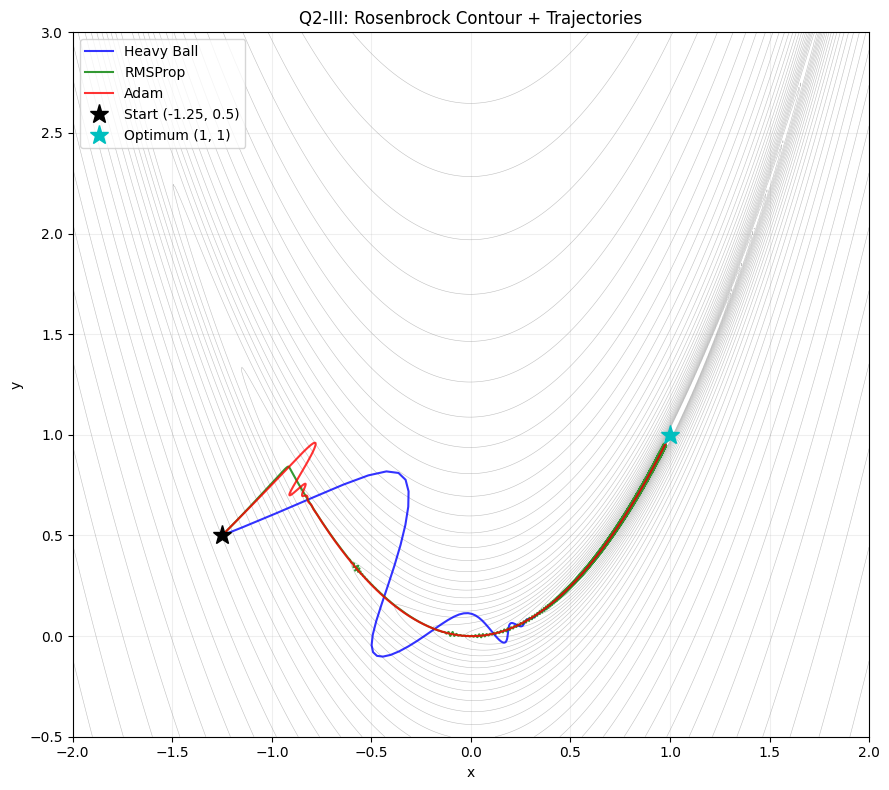

In [34]:
#question 2 - (III)

x_g2 = np.linspace(-2, 2, 500)
y_g2 = np.linspace(-0.5, 3, 500)
x2_mesh, y2_mesh = np.meshgrid(x_g2, y_g2)
Z2 = q2f2(x2_mesh, y2_mesh)

hist2_hb, _ = construct_heavyball(grad_q2f2, q2f2, x0_q2, alpha=2e-4, beta=0.9, itrs=itrs_q2)
hist2_rms, _ = construct_rmsprop(grad_q2f2, q2f2, x0_q2, alpha=0.01, beta=0.9, itrs=itrs_q2)
hist2_adam, _ = construct_adam(grad_q2f2, q2f2, x0_q2, alpha=0.05, beta1=0.9, beta2=0.999, itrs=itrs_q2)

fig, ax = plt.subplots(figsize=(9, 8))
levels2 = np.logspace(-1, 4, 40)
ax.contour(x2_mesh, y2_mesh, Z2, levels=levels2, colors='gray', linewidths=0.4, alpha=0.5)

ax.plot(hist2_hb[:, 0],  hist2_hb[:, 1],  'b-', alpha=0.8, label='Heavy Ball')
ax.plot(hist2_rms[:, 0], hist2_rms[:, 1], 'g-', alpha=0.8, label='RMSProp')
ax.plot(hist2_adam[:,0], hist2_adam[:,1],  'r-', alpha=0.8, label='Adam')

ax.plot(*x0_q2, 'k*', markersize=14, label='Start (-1.25, 0.5)')
ax.plot(1, 1, 'c*', markersize=14, label='Optimum (1, 1)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Q2-III: Rosenbrock Contour + Trajectories')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('q2_part3_contour.png', bbox_inches='tight')